# Ir free acidic OER stability landscape

Response to Reviewer 1, comment 1.3. Counts the GNoME materials that satisfy the acidic OER
aqueous stability criterion as a function of the $\Delta G_\text{pbx}$ cutoff, with the Ir
requirement removed.

Four panels. The top row uses the solid filter enabled, the bottom row uses it disabled, which is
the convention of the acidic OER case study in the article. The left column resolves the count by
element, with Ir as the reference. The right column takes the Ir free pool and applies
progressively stricter supply concentration limits, together with a platinum group metal free
restriction.

The window is $U = 1.2$ to $2.0$ V vs SHE at pH 0 and energies come from the GGA/GGA(+U)/r2SCAN
mixing scheme, matching the case study. The notebook locates the repository root itself, so it can
be run either from the root or from `paper/figures`.

## Configuration

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from aq_gnome import Data_Handler, Stable_Entries, Stability_Criteria

def repository_root(start=None):
    """Locate the repository root from anywhere inside it, so the notebook can be run
    either from the root or from paper/figures."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "data").is_dir() and (candidate / "paper" / "figures").is_dir():
            return candidate
    raise RuntimeError(f"repository root not found above {here}")


ROOT = repository_root()
HERE = ROOT / "paper" / "figures"
CACHE = HERE / "cache_maxdG_OER.csv"
OUT = HERE / "irfree_OER_landscape"
print("writing to", HERE)

US = [1.2, 2.0]          # acidic OER window, V vs SHE
PHS = [0]
CUTOFF = 0.2             # cutoff used in the article, marked on the figure
THRESHOLDS = np.linspace(0.0, 0.5, 101)

RADIOACTIVE = ['Tc', 'Ra', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt', 'Ds', 'Rg', 'Cn', 'Nh',
               'Fl', 'Mc', 'Lv', 'Ts', 'Og', 'Pm', 'Ac', 'Th', 'Pa', 'U', 'Np', 'Pu',
               'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No', 'Lr', 'Po', 'At', 'Rn']
REACTIVE_WITH_WATER = ['Li', 'Na', 'K', 'Rb', 'Cs', 'Fr', 'Ca', 'Ba']
TOXIC = ['Tl', 'Pb', 'As', 'Cd', 'Hg']
EXCLUDED = RADIOACTIVE + TOXIC + REACTIVE_WITH_WATER + ['F', 'Se', 'Te', 'B', 'P', 'S', 'Cl', 'C']

PGM = {'Ru', 'Rh', 'Pd', 'Os', 'Ir', 'Pt'}
ELEMENTS_PANEL = ['Ir', 'Rh', 'Ru', 'Mn', 'Co', 'Ni']
# Platinum group solid, 3d metals broken, so the two families separate by style as well
# as by colour.
ELEMENT_STYLES = {'Mn': '--', 'Co': ':', 'Ni': '--'}
HHI_LIMITS = [5500, 4000, 3000, 2000, 1000]   # 5500 is the HHI_P of elemental Ir

# Same palette as the other figures in this repository.
col_list = sns.color_palette("colorblind", 100)

# Matching Figure 5 of the article, which is drawn at matplotlib default text sizes.
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
})
LINEWIDTH = 1.7

# Panels a and c: one colour per element, assigned in fixed order.
COLORS = [col_list[i] for i in range(len(ELEMENTS_PANEL))]

# Panels b and d: the HHI limits are ordered magnitudes rather than separate identities,
# so they take one hue running light to dark as the limit tightens, anchored on col_list[0].
HHI_COLORS = sns.light_palette(col_list[0], n_colors=len(HHI_LIMITS) + 2)[2:]
PGM_COLOR = col_list[3]
TOTAL_COLOR = "0.15"

writing to C:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\GNoME_aqueous_stability\paper\figures


## Compute the window maxima

One maximum per material per solid filter setting. This is the expensive step, a few minutes per
setting, and it is cached so that the plotting cells can be re run freely.

In [16]:
def window_maxima(solid_filter):
    '''Max Delta G_pbx over the acidic OER window for every material of the pool.'''
    dh = Data_Handler(solid_filter=solid_filter, gga_only=False)
    dh.remove_entries_with_elements(EXCLUDED)

    se = Stable_Entries(dh, [])
    sc = Stability_Criteria(Us=US, pHs=PHS, decomposition_threshold=CUTOFF)

    df = dh.get_df()
    values = np.empty(len(df), dtype=np.float32)
    for i, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df))):
        values[i] = max(0.0, sc.max_dG_in_region(se.get_decom_G(row)))
    return df, values


def build_cache():
    df_off, v_off = window_maxima(False)
    df_on, v_on = window_maxima(True)

    off = pd.DataFrame({
        "MaterialId": df_off["MaterialId"].to_numpy(),
        "Reduced Formula": df_off["Reduced Formula"].to_numpy(),
        "Elements": [";".join(e) for e in df_off["Elements"]],
        "maxdG_off": v_off,
        "average_HHI_P_excluding_O_H": df_off["average_HHI_P_excluding_O_H"].to_numpy(),
    })
    on = pd.DataFrame({"MaterialId": df_on["MaterialId"].to_numpy(), "maxdG_on": v_on})

    out = off.merge(on, on="MaterialId")
    out.to_csv(CACHE, index=False)
    return out


df = pd.read_csv(CACHE) if CACHE.exists() else build_cache()
elements = df["Elements"].apply(lambda s: set(str(s).split(";")))
print(f"pool after element exclusions: {len(df)}")

pool after element exclusions: 245442


## Check against the article

The Ir branch of this pool is the acidic OER case study, so its numbers must reproduce the
article.

In [17]:
ir = elements.apply(lambda s: "Ir" in s)
print(f"Ir containing               {int(ir.sum()):>7}")
print(f"stable at {CUTOFF} eV/atom, filter off {int((df.maxdG_off[ir] <= CUTOFF).sum()):>7}   (article reports 73)")
print(f"stable at {CUTOFF} eV/atom, filter on  {int((df.maxdG_on[ir] <= CUTOFF).sum()):>7}")

Ir containing                 41690
stable at 0.2 eV/atom, filter off      73   (article reports 73)
stable at 0.2 eV/atom, filter on      224


## Figure

wrote C:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\GNoME_aqueous_stability\paper\figures\irfree_OER_landscape.pdf and C:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\GNoME_aqueous_stability\paper\figures\irfree_OER_landscape.png


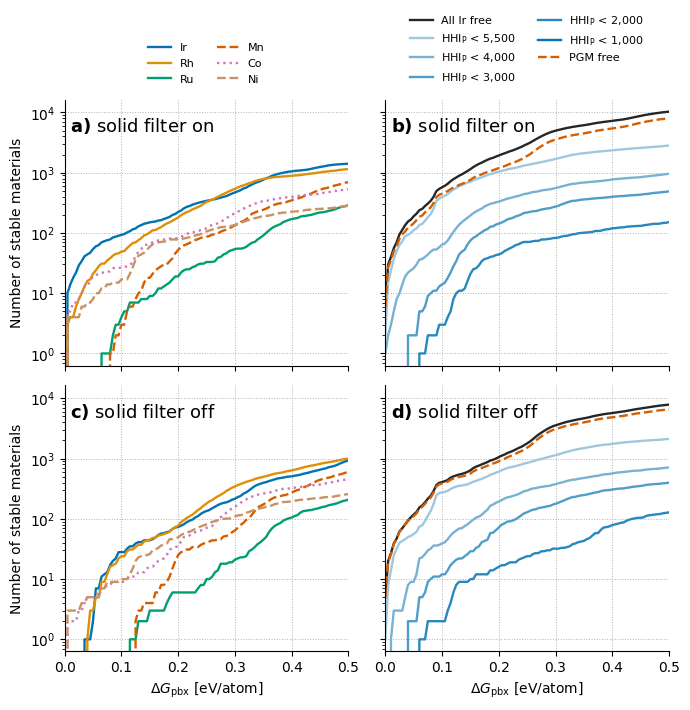

In [20]:
def counts(values):
    '''Number of materials at or below each cutoff.'''
    values = np.sort(np.asarray(values))
    return np.searchsorted(values, THRESHOLDS, side="right")


def panel_label(ax, letter, text):
    """Panel letter and solid filter setting, inside the axes at the top left."""
    ax.text(0.02, 0.94, rf"$\bf{{{letter})}}$ {text}", transform=ax.transAxes,
            fontsize=13, va="top")


# 7.0 in is the full text width of the two column layout, so the figure is drawn at the
# size it is printed and its text matches Figure 5 of the article.
fig, axes = plt.subplots(2, 2, figsize=(7.0, 7.2), sharex=True, sharey=True)
fig.patch.set_facecolor("white")
ir_free = ~ir

for row, (column, label) in enumerate([("maxdG_on", "solid filter on"),
                                       ("maxdG_off", "solid filter off")]):
    ax = axes[row, 0]
    for color, el in zip(COLORS, ELEMENTS_PANEL):
        # Element curves exclude Ir containing materials, so they are disjoint from the Ir
        # curve and can be read as the Ir free options containing that element.
        sel = elements.apply(lambda s, e=el: e in s) & (ir_free | (el == "Ir"))
        ax.plot(THRESHOLDS, counts(df.loc[sel, column]), color=color, lw=LINEWIDTH, label=el,
                ls=ELEMENT_STYLES.get(el, "-"))
    ax.set_ylabel("Number of stable materials")
    panel_label(ax, 'ac'[row], label)

    ax = axes[row, 1]
    sub, sub_elements = df[ir_free], elements[ir_free]
    ax.plot(THRESHOLDS, counts(sub[column]), color=TOTAL_COLOR, lw=LINEWIDTH, label="All Ir free")
    for color, limit in zip(HHI_COLORS, HHI_LIMITS):
        sel = sub["average_HHI_P_excluding_O_H"] < limit
        ax.plot(THRESHOLDS, counts(sub.loc[sel, column]), color=color, lw=LINEWIDTH,
                label=f"HHI$_\\mathrm{{P}}$ < {limit:,}")
    pgm_free = sub_elements.apply(lambda s: not (s & PGM))
    ax.plot(THRESHOLDS, counts(sub.loc[pgm_free, column]), color=PGM_COLOR, lw=LINEWIDTH, ls="--",
            label="PGM free")
    panel_label(ax, 'bd'[row], label)

for ax in axes.flat:
    ax.set_yscale("log")
    ax.set_xlim(0, 0.5)
    # ax.axvline(CUTOFF, color="0.5", lw=0.8, ls=":", zorder=0)
    ax.grid(linestyle=":", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.set_facecolor("white")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
# One legend per column, above the top row, since both rows share the same series.
for col in (0, 1):
    axes[0, col].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False,
                        fontsize=8, ncols=2)

for ax in axes[1]:
    ax.set_xlabel(r"$\Delta G_{\mathrm{pbx}}$ [eV/atom]")

fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(f"{OUT}.{ext}", dpi=600, bbox_inches="tight")
print(f"wrote {OUT}.pdf and {OUT}.png")

## Counts at the cutoff used in the article

In [19]:
rows = []
for column, label in [("maxdG_on", "filter on"), ("maxdG_off", "filter off")]:
    for el in ELEMENTS_PANEL:
        sel = elements.apply(lambda s, e=el: e in s) & (ir_free | (el == "Ir"))
        rows.append({"convention": label, "set": el, "n": int((df.loc[sel, column] <= CUTOFF).sum())})
    sub, sub_elements = df[ir_free], elements[ir_free]
    rows.append({"convention": label, "set": "All Ir free", "n": int((sub[column] <= CUTOFF).sum())})
    for limit in HHI_LIMITS:
        sel = sub["average_HHI_P_excluding_O_H"] < limit
        rows.append({"convention": label, "set": f"Ir free, HHI < {limit}",
                     "n": int((sub.loc[sel, column] <= CUTOFF).sum())})
    pgm_free = sub_elements.apply(lambda s: not (s & PGM))
    rows.append({"convention": label, "set": "Ir free, PGM free",
                 "n": int((sub.loc[pgm_free, column] <= CUTOFF).sum())})

pd.DataFrame(rows).pivot(index="set", columns="convention", values="n")

convention,filter off,filter on
set,,
All Ir free,1058,1933
Co,35,82
Ir,73,224
"Ir free, HHI < 1000",0,0
"Ir free, HHI < 2000",16,44
"Ir free, HHI < 3000",72,143
"Ir free, HHI < 4000",193,331
"Ir free, HHI < 5500",610,1038
"Ir free, PGM free",905,1193
